# Data-efficiency — Plain Multires, \(n_{\mathrm{train}}=2498\)

Follows `PROTOCOL.txt` / `PROTOCOL.docx` in this folder (**plain** network only, \(\lambda=0\)).

| Item | Value |
|------|-------|
| Data | **Spectrally filtered C1** (same as `filtered_c1_multires_2k_diagnostics_NB.ipynb`) |
| Model | Multires, \(\lambda=0\) |
| \(n_{\mathrm{train}}\) | 2498 |
| \(n_{\mathrm{val}}\) / \(n_{\mathrm{test}}\) | 200 / 512 (shared seeds; identical across the campaign) |
| Batch \(B\) | 300 |
| LR grid | \(\{10^{-4},\ 10^{-3},\ 10^{-2}\}\) + edge expansion if needed; then final with LR\* |
| Early stop | \(patience\_steps=25\cdot K\); screen \(max\_steps=100\cdot K\); final \(max\_steps=200\cdot K\); \(K=\lceil n/B\rceil\) |
| HP screens | plot train/val pulse L1 (raw+amb) and TRACE L1 for each LR (sanity) |
| Train/val SNR | U[0, 30] dB |
| Snapshots (final) | every 2 epochs, fixed val sample @ SNR=10 dB |

Artifacts: `checkpoints/n2498_plain/` under this folder.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
# Ensure figures embed in the notebook when executed headlessly / in Cursor
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

from pathlib import Path
import json
import math
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

HERE = Path.cwd()
# Allow running with cwd = this folder OR parent src/
if (HERE / "setup_src_path.py").exists():
    sys.path.insert(0, str(HERE))
    import setup_src_path  # noqa: F401
    EXP = HERE
    SRC = HERE.parent
elif (HERE / "data efficiency experiment" / "setup_src_path.py").exists():
    EXP = HERE / "data efficiency experiment"
    sys.path.insert(0, str(EXP))
    import setup_src_path  # noqa: F401
    SRC = HERE
else:
    raise RuntimeError("Run from src/ or from data efficiency experiment/")

import data_c_amb_loss_diagnostics as diag
from data_generation import filtered_c1_pulse_config
from dataset_utils import build_filtered_c1_frog_dataloaders
from evaluate_cnn import load_cnn_sweep
from frog_reconstruction_model import extract_pulse_prediction
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    best_similarity_error_ambiguity,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)
from trace_noise import add_trace_noise_awgn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = EXP / "checkpoints" / "n2498_plain"
OUT.mkdir(parents=True, exist_ok=True)

N_TRAIN = 2498
N_VAL = 200
N_TEST = 512
BATCH_SIZE = 300
SEED = 0  # val=seed+1, test=seed+2 → shared across campaign
LR_GRID = [1e-4, 1e-3, 1e-2]
EARLY_STOP_MODE = "steps"
TRAIN_SNR = (0.0, 30.0)
VAL_SNR = (0.0, 30.0)
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)
SNAPSHOT_EVERY_FINAL = 2
SNAPSHOT_SNR_DB = 10.0
SNAPSHOT_VAL_INDEX = 0
SNAPSHOT_NOISE_SEED = 12345

STEPS_PER_EPOCH = math.ceil(N_TRAIN / BATCH_SIZE)  # K
PATIENCE_STEPS = 25 * STEPS_PER_EPOCH
MAX_STEPS_SCREEN = 100 * STEPS_PER_EPOCH
MAX_STEPS_FINAL = 200 * STEPS_PER_EPOCH
MAX_EPOCHS_SCREEN = max(1, math.ceil(MAX_STEPS_SCREEN / STEPS_PER_EPOCH))
MAX_EPOCHS_FINAL = max(1, math.ceil(MAX_STEPS_FINAL / STEPS_PER_EPOCH))

# Protocol budgets (25/100/200 epochs via K) — skip completed trains
FORCE_RETRAIN = False
FORCE_TEST_SWEEP = False  # sweep already saved; set True to recompute

print("device:", DEVICE)
print("EXP:", EXP.resolve())
print("OUT:", OUT.resolve())
print("pulse cfg:", filtered_c1_pulse_config(n=64))
print(
    f"n_train={N_TRAIN}  B={BATCH_SIZE}  K={STEPS_PER_EPOCH}  "
    f"patience_steps={PATIENCE_STEPS} (=25 ep)  "
    f"screen max_steps={MAX_STEPS_SCREEN} (=100 ep)  "
    f"final max_steps={MAX_STEPS_FINAL} (=200 ep)"
)
print("LR grid:", LR_GRID)
print(f"early_stop: {EARLY_STOP_MODE}")


device: cuda
EXP: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment
OUT: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\n2498_plain
pulse cfg: FilteredC1PulseConfig(n=64, t_total_fs=70.0, n_spikes=500, central_energy_ev=10000.0, coherence_time_fs=1.0, t_center_std_fs=5.73, delta_energy_ev_range=0.00065, fwhm_ev=0.45, amplitude_min=0.75, amplitude_max=1.0, use_delta_omega=True)
n_train=2498  B=300  K=9  patience_steps=225 (=25 ep)  screen max_steps=900 (=100 ep)  final max_steps=1800 (=200 ep)
LR grid: [0.0001, 0.001, 0.01]
early_stop: steps


## Helpers


In [2]:
def lr_tag(lr: float) -> str:
    s = f"{float(lr):g}".replace(".", "p").replace("-", "m")
    return f"n{N_TRAIN}_plain_lr{s}"


def load_meta(tag: str) -> dict:
    return json.loads((OUT / f"{tag}_meta.json").read_text(encoding="utf-8"))


def train_plain(
    tag: str,
    *,
    lr: float,
    snapshot_every: int,
    role: str,
    max_steps: int,
    max_epochs: int,
):
    hist_path = OUT / f"{tag}_history.npz"
    if hist_path.exists() and not FORCE_RETRAIN:
        print(f"skip {role}; using", hist_path)
        return None
    print(
        f"=== {role}: {tag}  lr={lr:g}  early_stop={EARLY_STOP_MODE}"
        f"(patience_steps={PATIENCE_STEPS})  max_steps={max_steps}  "
        f"snap_every={snapshot_every} ==="
    )
    t0 = time.perf_counter()
    result = diag.train_data_c_amb_diagnostics(
        pulse_loss_mode="raw",
        lam=0.0,
        n_train=N_TRAIN,
        n_val=N_VAL,
        n_test=N_TEST,
        batch_size=BATCH_SIZE,
        seed=SEED,
        max_epochs=int(max_epochs),
        patience=int(PATIENCE_STEPS),  # steps when early_stop_mode="steps"
        lr=float(lr),
        train_snr_db_range=TRAIN_SNR,
        val_snr_db_range=VAL_SNR,
        device=DEVICE,
        verbose=True,
        ambiguity_backend="legacy",
        trace_loss_ref="clean",
        loader_builder="filtered_c1",
        canonicalize_mode="t0",
        max_steps=int(max_steps),
        snapshot_every=int(snapshot_every),
        snapshot_snr_db=SNAPSHOT_SNR_DB,
        snapshot_val_index=SNAPSHOT_VAL_INDEX,
        snapshot_noise_seed=SNAPSHOT_NOISE_SEED,
        early_stop_mode=EARLY_STOP_MODE,
    )
    result_save = {k: v for k, v in result.items() if k != "bundle"}
    result_save["role"] = role
    diag.save_run_artifacts(result_save, OUT, tag)
    meta = load_meta(tag)
    meta["role"] = role
    meta["wall_time_total_sec"] = float(time.perf_counter() - t0)
    (OUT / f"{tag}_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(json.dumps(meta, indent=2))
    return result


def summarize_timings(hist, name):
    keys = [
        "timing_data_prep_sec",
        "timing_loss_data_fwd_sec",
        "timing_loss_reg_fwd_sec",
        "timing_total_backward_sec",
        "timing_optimizer_step_sec",
    ]
    print(f"=== {name}: mean±std over epochs (ms/batch) ===")
    for k in keys:
        if k not in hist:
            continue
        x = np.asarray(hist[k], dtype=float) * 1e3
        print(f"  {k.replace('timing_', ''):22s}  {x.mean():7.3f} ± {x.std():6.3f}")


def plot_pulse_curves(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["train_pulse_l1_raw"], label="raw")
    axes[0].plot(hist["train_pulse_l1_amb"], label="best-amb")
    axes[0].set_title(f"{title_prefix}: train pulse L1")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist["val_pulse_l1_raw"], label="raw")
    axes[1].plot(hist["val_pulse_l1_amb"], label="best-amb")
    axes[1].set_title(f"{title_prefix}: val pulse L1 (SNR~U[0,30])")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_trace_curves(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["train_trace_l1"])
    axes[0].set_title(f"{title_prefix}: train TRACE L1")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist["val_trace_l1"])
    axes[1].set_title(f"{title_prefix}: val TRACE L1 (SNR~U[0,30])")
    axes[1].set_xlabel("epoch")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_grad_norms(hist, title_prefix, lam=0.0):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(hist["grad_norm_data"], label=r"$||\nabla L_{\mathrm{data}}||$")
    if float(lam) > 0.0:
        ax.semilogy(hist["grad_norm_reg"], label=r"$||\nabla L_{\mathrm{reg}}||$")
        if "grad_norm_total" in hist and len(hist["grad_norm_total"]):
            ax.semilogy(hist["grad_norm_total"], label=r"$||\nabla L_{\mathrm{total}}||$")
    else:
        ax.semilogy(
            hist["grad_norm_reg"],
            label=r"$||\nabla L_{\mathrm{reg}}||$ (NOT in loss)",
            alpha=0.7,
        )
        if "grad_norm_total" in hist and len(hist["grad_norm_total"]):
            ax.semilogy(hist["grad_norm_total"], label=r"$||\nabla L_{\mathrm{total}}||=||\nabla L_{\mathrm{data}}||$")
    ax.set_xlabel("epoch")
    ax.set_title(f"{title_prefix}: gradient norms")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## LR screening (plain, $\lambda=0$) + sanity curves


skip lr_screen; using D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\n2498_plain\n2498_plain_lr0p0001_screen_history.npz


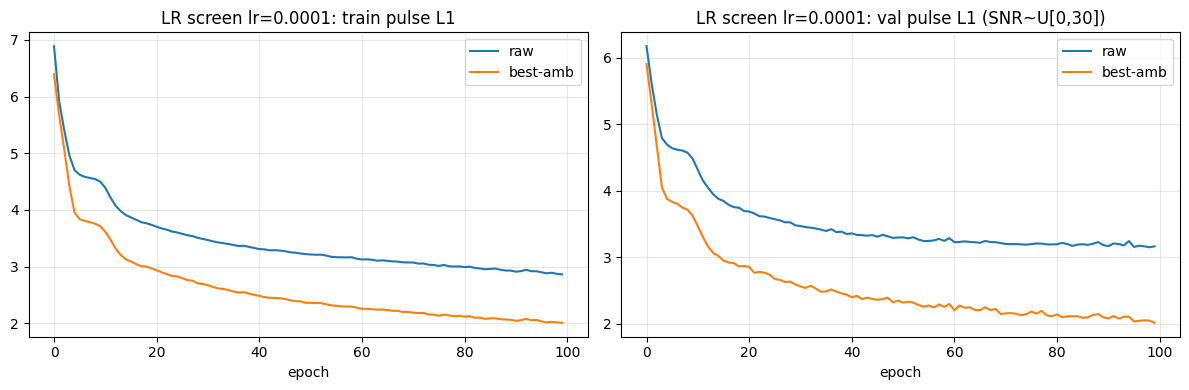

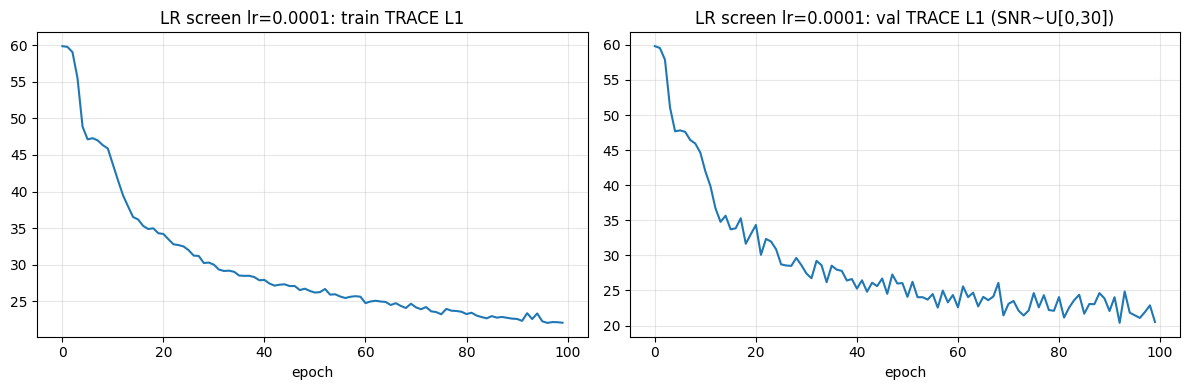

skip lr_screen; using D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\n2498_plain\n2498_plain_lr0p001_screen_history.npz


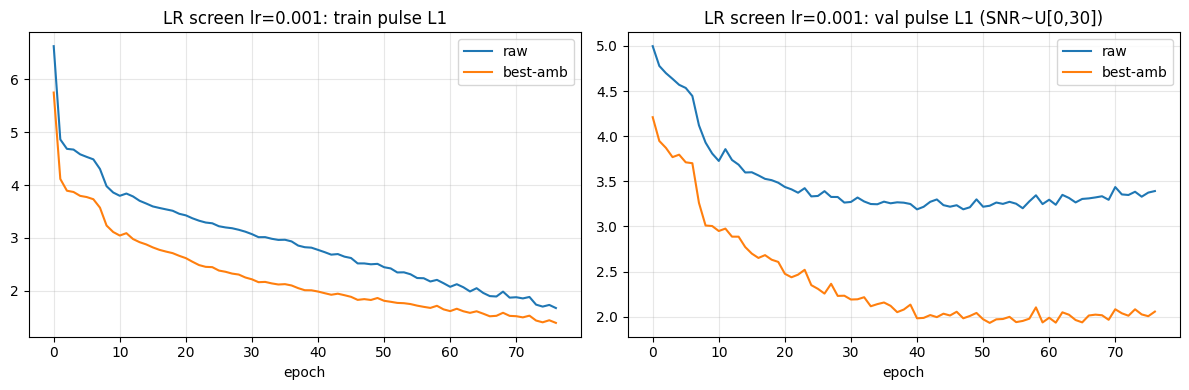

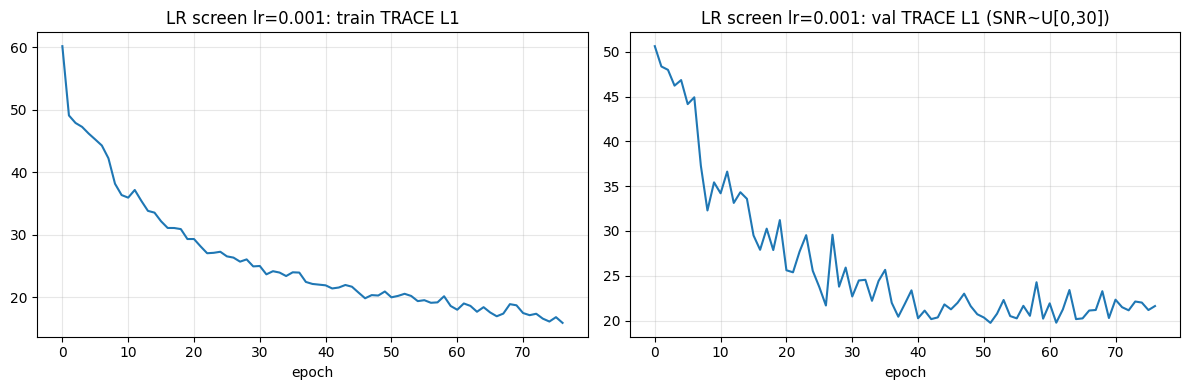

skip lr_screen; using D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\n2498_plain\n2498_plain_lr0p01_screen_history.npz


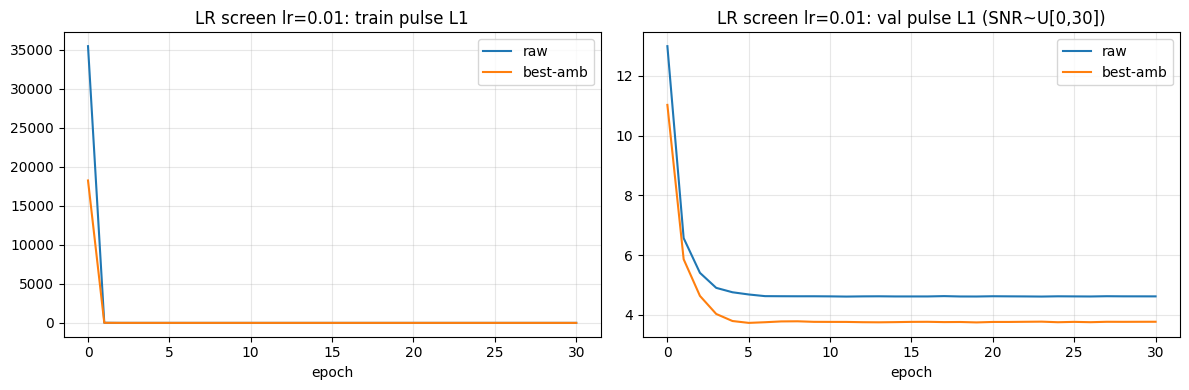

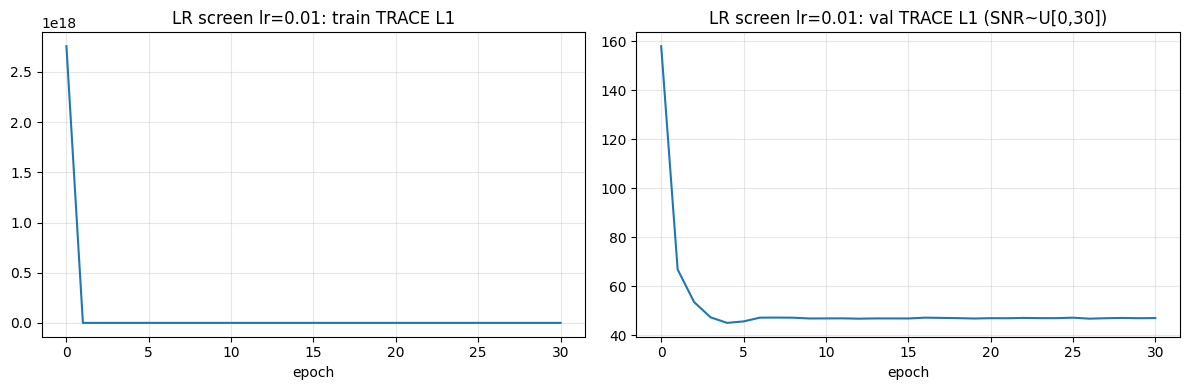

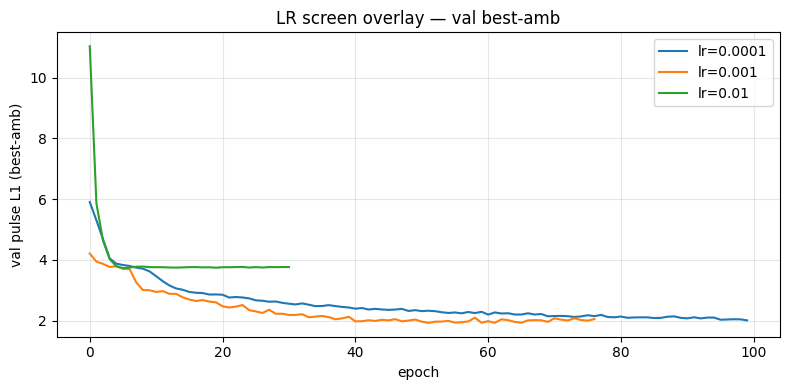


=== LR screening summary ===
  lr=0.0001  best_score=2.012920  best_epoch=100  best_step=900  stopped=100
  lr=0.001  best_score=1.931268  best_epoch=52  best_step=468  stopped=77
  lr=0.01  best_score=3.730007  best_epoch=6  best_step=54  stopped=31

LR* = 0.001


827

In [3]:
def screen_one_lr(lr: float) -> dict:
    tag = lr_tag(lr) + "_screen"
    train_plain(
        tag,
        lr=lr,
        snapshot_every=0,
        role="lr_screen",
        max_steps=MAX_STEPS_SCREEN,
        max_epochs=MAX_EPOCHS_SCREEN,
    )
    hist = diag.load_history(OUT / f"{tag}_history.npz")
    meta = load_meta(tag)
    plot_pulse_curves(hist, f"LR screen lr={lr:g}")
    plot_trace_curves(hist, f"LR screen lr={lr:g}")
    return {
        "lr": float(lr),
        "tag": tag,
        "best_score": float(meta["best_score"]),
        "best_epoch": int(meta["best_epoch"]),
        "best_step": int(meta.get("best_step", -1)),
        "stopped_epoch": int(meta["stopped_epoch"]),
        "global_step": meta.get("global_step"),
        "wall_time_train_sec": meta.get("wall_time_train_sec"),
    }


def expand_edge_lrs(lr_star: float, grid: list[float]) -> list[float]:
    g = sorted(float(x) for x in grid)
    lo, hi = g[0], g[-1]
    extra = []
    if abs(lr_star - lo) <= 1e-15 * max(1.0, abs(lo)):
        extra = [3e-5, 1e-5]
        print(f"LR* at lower edge ({lo:g}); expanding with", extra)
    elif abs(lr_star - hi) <= 1e-15 * max(1.0, abs(hi)):
        extra = [3e-2, 1e-1]
        print(f"LR* at upper edge ({hi:g}); expanding with", extra)
    return extra


screen_rows = []
active_grid = list(LR_GRID)
for lr in active_grid:
    screen_rows.append(screen_one_lr(lr))

best = min(screen_rows, key=lambda r: float(r["best_score"]))
LR_STAR = float(best["lr"])
extra = expand_edge_lrs(LR_STAR, active_grid)
for lr in extra:
    if any(abs(lr - r["lr"]) < 1e-18 for r in screen_rows):
        continue
    screen_rows.append(screen_one_lr(lr))
    active_grid.append(lr)

best = min(screen_rows, key=lambda r: float(r["best_score"]))
LR_STAR = float(best["lr"])

# Overlay val best-amb for sanity
fig, ax = plt.subplots(figsize=(8, 4))
for r in sorted(screen_rows, key=lambda x: x["lr"]):
    h = diag.load_history(OUT / f"{r['tag']}_history.npz")
    ax.plot(h["val_pulse_l1_amb"], label=f"lr={r['lr']:g}")
ax.set_xlabel("epoch")
ax.set_ylabel("val pulse L1 (best-amb)")
ax.set_title("LR screen overlay — val best-amb")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== LR screening summary ===")
for r in sorted(screen_rows, key=lambda x: x["lr"]):
    print(
        f"  lr={r['lr']:g}  best_score={r['best_score']:.6f}  "
        f"best_epoch={r['best_epoch']}  best_step={r['best_step']}  "
        f"stopped={r['stopped_epoch']}"
    )
print(f"\nLR* = {LR_STAR:g}")
(OUT / "lr_screen_summary.json").write_text(
    json.dumps({"LR_STAR": LR_STAR, "rows": screen_rows}, indent=2),
    encoding="utf-8",
)


## Final plain training with LR*


In [4]:
TAG_FINAL = lr_tag(LR_STAR) + "_final"
train_plain(
    TAG_FINAL,
    lr=LR_STAR,
    snapshot_every=SNAPSHOT_EVERY_FINAL,
    role="final",
    max_steps=MAX_STEPS_FINAL,
    max_epochs=MAX_EPOCHS_FINAL,
)
hist = diag.load_history(OUT / f"{TAG_FINAL}_history.npz")
meta = load_meta(TAG_FINAL)
print(json.dumps(meta, indent=2))


skip final; using D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\n2498_plain\n2498_plain_lr0p001_final_history.npz
{
  "best_epoch": 70,
  "best_score": 1.9460664850473404,
  "stopped_epoch": 95,
  "lam": 0.0,
  "trace_scale": 7.886867434917454,
  "pulse_loss_mode": "raw",
  "ambiguity_backend": "legacy",
  "trace_loss_ref": "clean",
  "device": "cuda",
  "train_snr_db_range": [
    0.0,
    30.0
  ],
  "train_snr_db_values": null,
  "val_snr_db_range": [
    0.0,
    30.0
  ],
  "val_snr_db_values": null,
  "n_train": 2498,
  "n_val": 200,
  "seed": 0,
  "loader_builder": "filtered_c1",
  "canonicalize_mode": "t0",
  "lr": 0.001,
  "batch_size": 300,
  "max_steps": 1800,
  "global_step": 855,
  "best_step": 630,
  "early_stop_mode": "steps",
  "early_stop_frac": 0.9,
  "patience": 225,
  "wall_time_data_sec": 29.26107809995301,
  "wall_time_train_sec": 1048.6167929999065,
  "role": "final",
  "wall_time_total_sec": 1078.8717987001874
}


## Final-run curves (pulse / TRACE / gradients / timings)


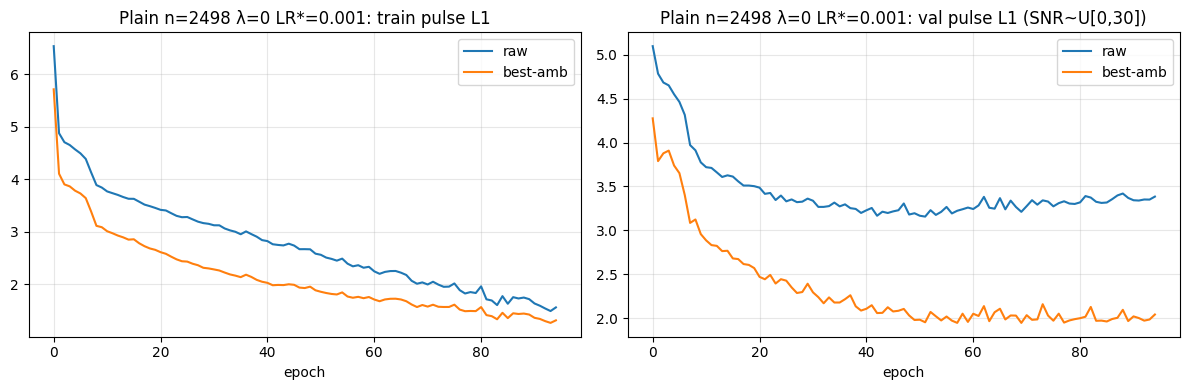

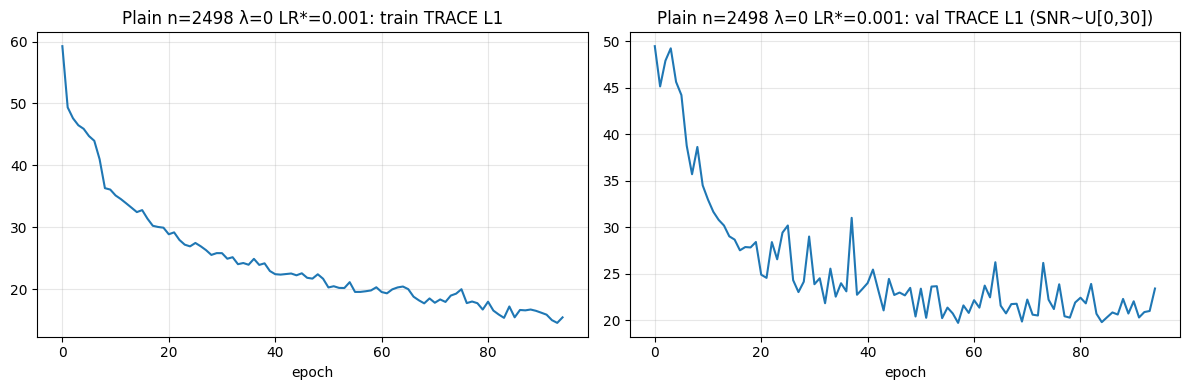

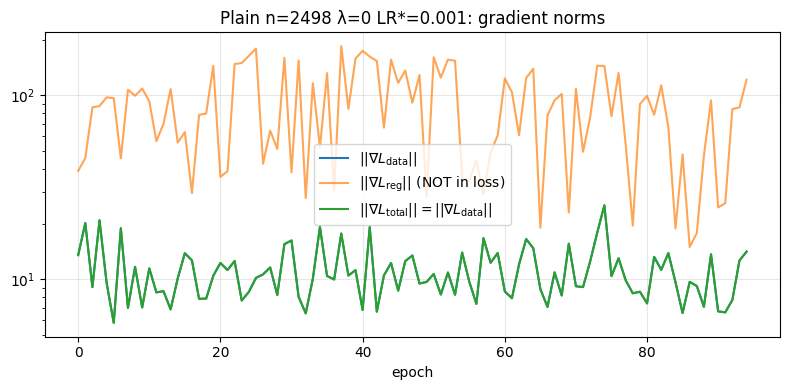

=== Plain n=2498 final: mean±std over epochs (ms/batch) ===
  data_prep_sec             1.799 ±  0.137
  loss_data_fwd_sec        70.007 ±  0.228
  loss_reg_fwd_sec         12.140 ±  0.686
  total_backward_sec      130.481 ±  0.607
  optimizer_step_sec        5.012 ±  0.075
wall_time_data_sec=29.26107809995301  wall_time_train_sec=1048.6167929999065  global_step=855


In [5]:
plot_pulse_curves(hist, f"Plain n={N_TRAIN} λ=0 LR*={LR_STAR:g}")
plot_trace_curves(hist, f"Plain n={N_TRAIN} λ=0 LR*={LR_STAR:g}")
plot_grad_norms(hist, f"Plain n={N_TRAIN} λ=0 LR*={LR_STAR:g}", lam=0.0)
summarize_timings(hist, f"Plain n={N_TRAIN} final")
print(
    f"wall_time_data_sec={meta.get('wall_time_data_sec')}  "
    f"wall_time_train_sec={meta.get('wall_time_train_sec')}  "
    f"global_step={meta.get('global_step')}"
)


## Snapshot evolution (val sample @ SNR=10 dB, every 2 epochs)


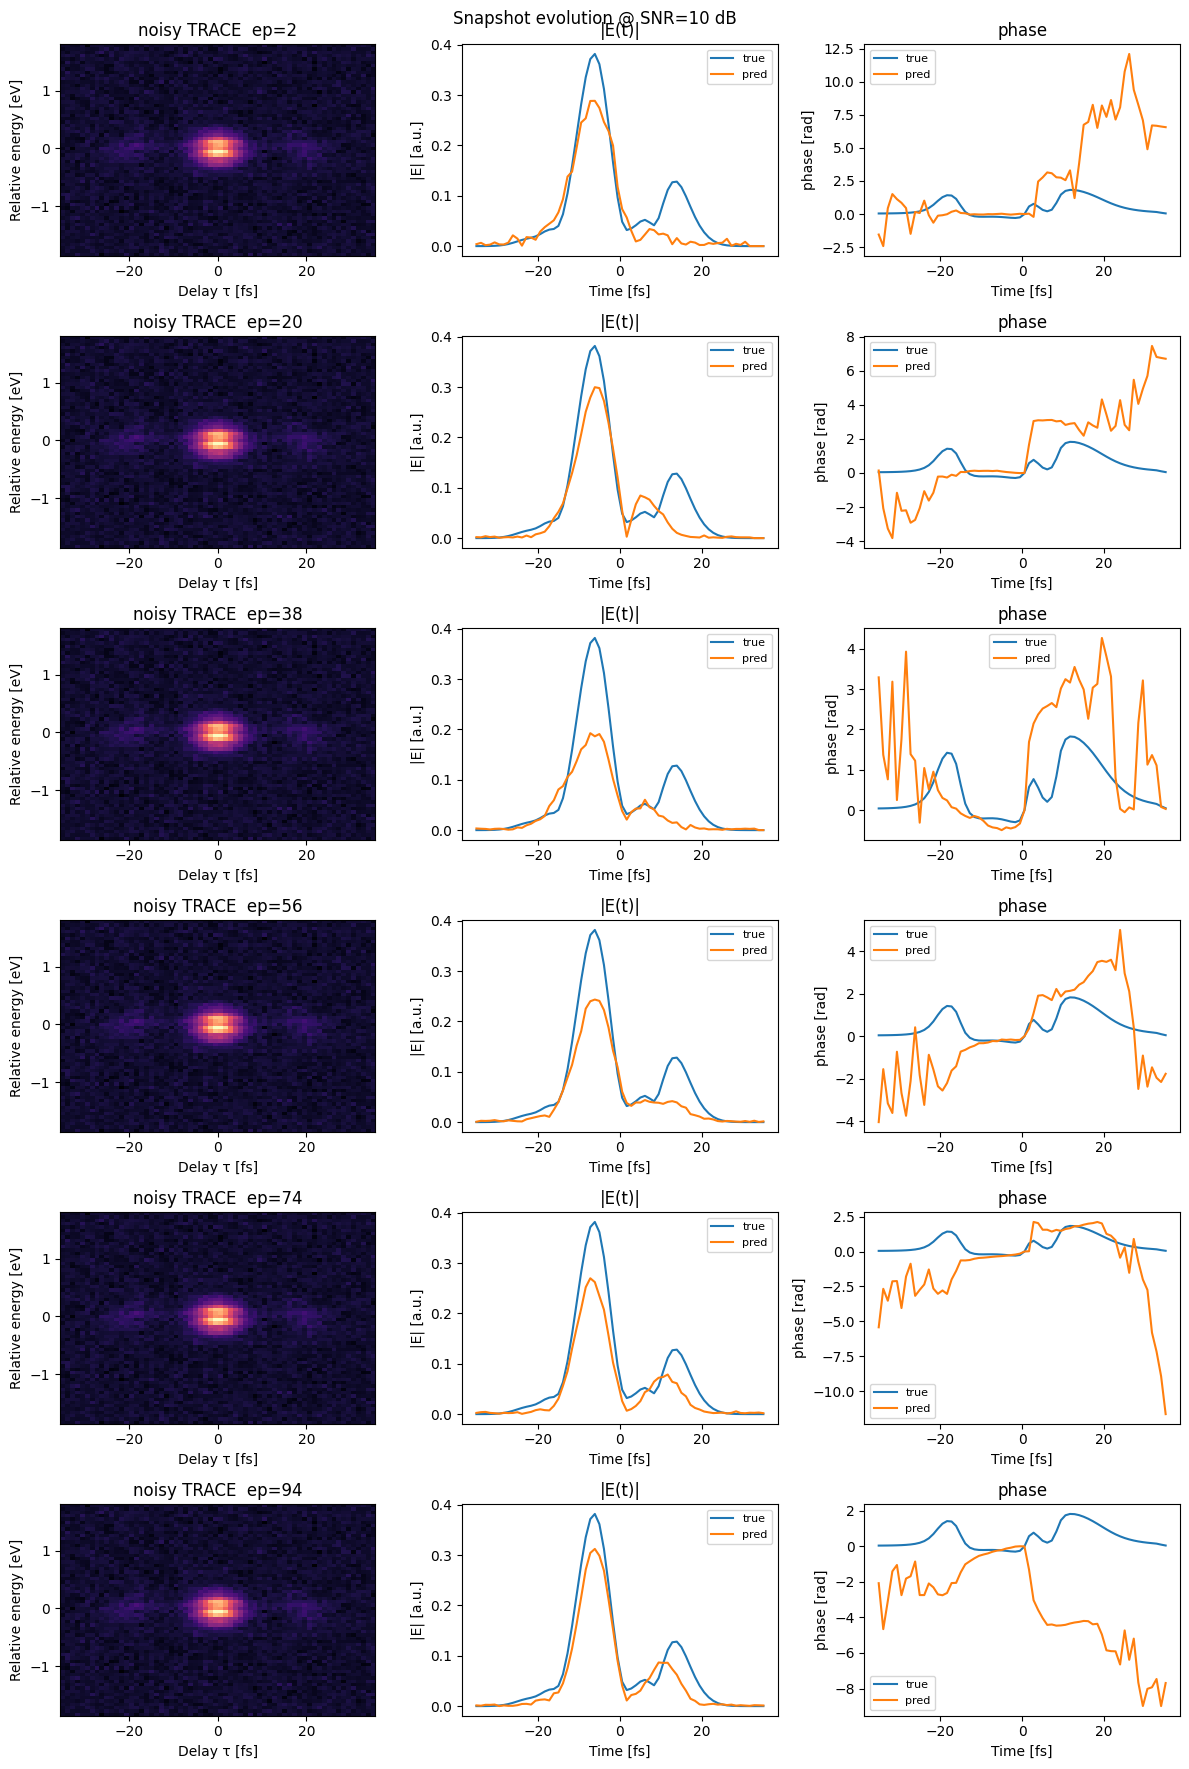

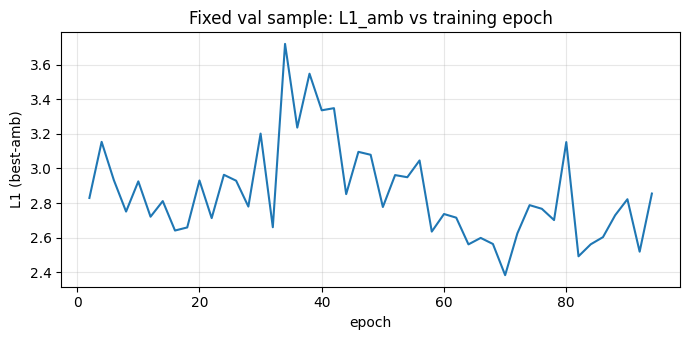

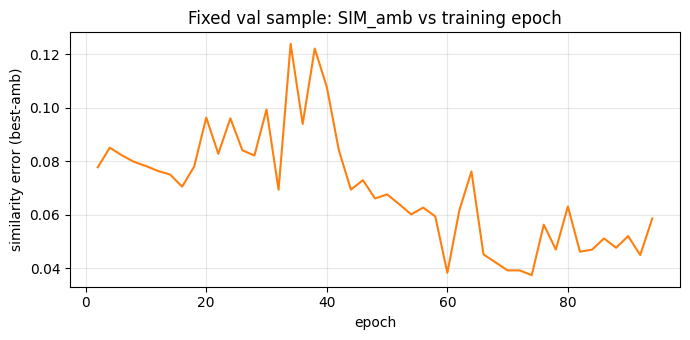

In [6]:
snap_path = OUT / f"{TAG_FINAL}_snapshots.npz"
assert snap_path.exists(), snap_path
snap = np.load(snap_path)
epochs = snap["epoch"]
E_pred_all = snap["E_pred"]  # [S, 128] packed or [S, 1, 128]
if E_pred_all.ndim == 3:
    E_pred_all = E_pred_all[:, 0, :]
E_true = snap["E_true"]
if E_true.ndim == 3:
    E_true = E_true[0]
elif E_true.ndim == 2 and E_true.shape[0] == 1:
    E_true = E_true[0]
I_noisy = snap["I_noisy"]
if I_noisy.ndim == 4:
    I_noisy = I_noisy[0, 0]
elif I_noisy.ndim == 3:
    I_noisy = I_noisy[0]

pulse_cfg = filtered_c1_pulse_config(n=64)
dt = float(pulse_cfg.dt)
t_axis = np.linspace(-pulse_cfg.t_total_fs / 2.0, pulse_cfg.t_total_fs / 2.0, pulse_cfg.n)
e_true = unpack_packed_field(E_true)
I_show, tau_axis, omega_plot = prepare_frog_trace_for_plot(
    I_noisy, num_points=pulse_cfg.n, dt=dt
)
energy_ev = omega_plot * 4.135667696 / (2.0 * np.pi)
extent = [tau_axis[0], tau_axis[-1], energy_ev[0], energy_ev[-1]]

# Six evenly spaced snapshots across training
n_show = min(6, len(epochs))
show_idx = np.unique(np.linspace(0, len(epochs) - 1, n_show, dtype=int)).tolist()
fig, axes = plt.subplots(len(show_idx), 3, figsize=(12, 3.0 * len(show_idx)))
if len(show_idx) == 1:
    axes = np.array([axes])
for row, si in enumerate(show_idx):
    e_pred = unpack_packed_field(E_pred_all[si])
    e_al = best_l1_ambiguity_field(e_pred, e_true)
    amp_p, amp_t = np.abs(e_al), np.abs(e_true)
    ph_t, ph_p = unwrap_phases_for_overlay(e_al, e_true)
    im = axes[row, 0].imshow(
        I_show, aspect="auto", origin="lower", extent=extent, cmap="magma"
    )
    axes[row, 0].set_title(f"noisy TRACE  ep={int(epochs[si])}")
    axes[row, 0].set_xlabel("Delay τ [fs]")
    axes[row, 0].set_ylabel("Relative energy [eV]")
    axes[row, 1].plot(t_axis, amp_t, label="true")
    axes[row, 1].plot(t_axis, amp_p, label="pred")
    axes[row, 1].set_title("|E(t)|")
    axes[row, 1].set_xlabel("Time [fs]")
    axes[row, 1].set_ylabel("|E| [a.u.]")
    axes[row, 1].legend(fontsize=8)
    axes[row, 2].plot(t_axis, ph_t, label="true")
    axes[row, 2].plot(t_axis, ph_p, label="pred")
    axes[row, 2].set_title("phase")
    axes[row, 2].set_xlabel("Time [fs]")
    axes[row, 2].set_ylabel("phase [rad]")
    axes[row, 2].legend(fontsize=8)
plt.suptitle(f"Snapshot evolution @ SNR={SNAPSHOT_SNR_DB:g} dB")
plt.tight_layout()
plt.show()

# Metric vs epoch for the fixed sample (separate scales)
l1s, sims = [], []
for i in range(len(epochs)):
    e_pred = unpack_packed_field(E_pred_all[i])
    l1s.append(best_l1_ambiguity(e_pred, e_true))
    sims.append(best_similarity_error_ambiguity(e_pred, e_true))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epochs, l1s, color="C0")
ax.set_xlabel("epoch")
ax.set_ylabel("L1 (best-amb)")
ax.set_title("Fixed val sample: L1_amb vs training epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epochs, sims, color="C1")
ax.set_xlabel("epoch")
ax.set_ylabel("similarity error (best-amb)")
ax.set_title("Fixed val sample: SIM_amb vs training epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Held-out test SNR sweep


skip sweep; using D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\n2498_plain\n2498_plain_lr0p001_final_test_snr_sweep.npz


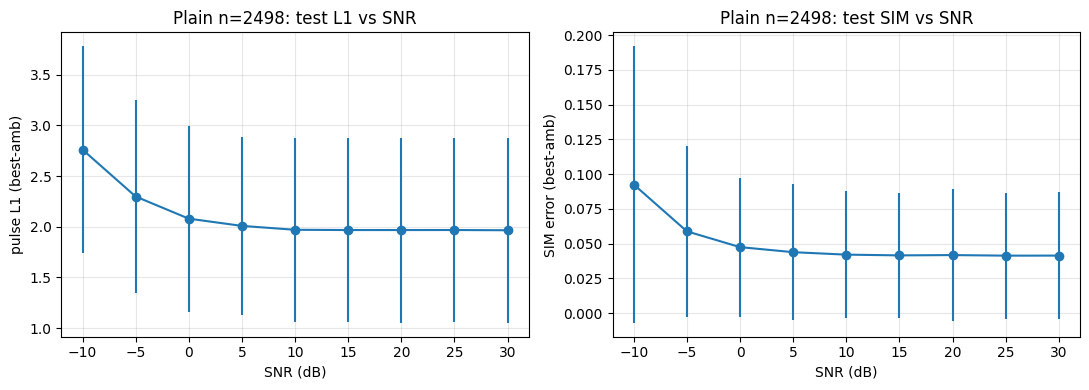

  SNR= -10.0  L1_amb=2.7610  SIM_amb=0.0925
  SNR=  -5.0  L1_amb=2.2982  SIM_amb=0.0588
  SNR=   0.0  L1_amb=2.0799  SIM_amb=0.0475
  SNR=   5.0  L1_amb=2.0084  SIM_amb=0.0439
  SNR=  10.0  L1_amb=1.9700  SIM_amb=0.0421
  SNR=  15.0  L1_amb=1.9675  SIM_amb=0.0415
  SNR=  20.0  L1_amb=1.9674  SIM_amb=0.0418
  SNR=  25.0  L1_amb=1.9677  SIM_amb=0.0414
  SNR=  30.0  L1_amb=1.9654  SIM_amb=0.0414


In [7]:
# Shared test loader (seed+2), same for all campaign models
bundle = build_filtered_c1_frog_dataloaders(
    n_train=max(N_TRAIN, 64),
    n_val=N_VAL,
    n_test=N_TEST,
    batch_size=BATCH_SIZE,
    seed=SEED,
    device=DEVICE,
    grid=filtered_c1_pulse_config(n=64),
    canonicalize_mode="t0",
)
test_loader = bundle.test_loader

sweep_path = OUT / f"{TAG_FINAL}_test_snr_sweep.npz"
if FORCE_TEST_SWEEP or not sweep_path.exists():
    print("Running test SNR sweep...")
    diag.run_and_save_test_snr_sweep(
        OUT / f"{TAG_FINAL}_model.pt",
        sweep_path,
        test_loader=test_loader,
        snr_sweep_db=SNR_SWEEP_DB,
        device=DEVICE,
        experiment_name=f"Plain n={N_TRAIN} LR*={LR_STAR:g}",
    )
else:
    print("skip sweep; using", sweep_path)

sweep = load_cnn_sweep(sweep_path)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(sweep.snr_sweep_db, sweep.cnn_l1_amb_m, yerr=sweep.cnn_l1_amb_s, marker="o")
axes[0].set_xlabel("SNR (dB)")
axes[0].set_ylabel("pulse L1 (best-amb)")
axes[0].set_title(f"Plain n={N_TRAIN}: test L1 vs SNR")
axes[0].grid(True, alpha=0.3)
axes[1].errorbar(sweep.snr_sweep_db, sweep.cnn_sim_amb_m, yerr=sweep.cnn_sim_amb_s, marker="o")
axes[1].set_xlabel("SNR (dB)")
axes[1].set_ylabel("SIM error (best-amb)")
axes[1].set_title(f"Plain n={N_TRAIN}: test SIM vs SNR")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
for snr, l1, sim in zip(sweep.snr_sweep_db, sweep.cnn_l1_amb_m, sweep.cnn_sim_amb_m):
    print(f"  SNR={snr:6.1f}  L1_amb={l1:.4f}  SIM_amb={sim:.4f}")


## Test example @ SNR = 10 dB


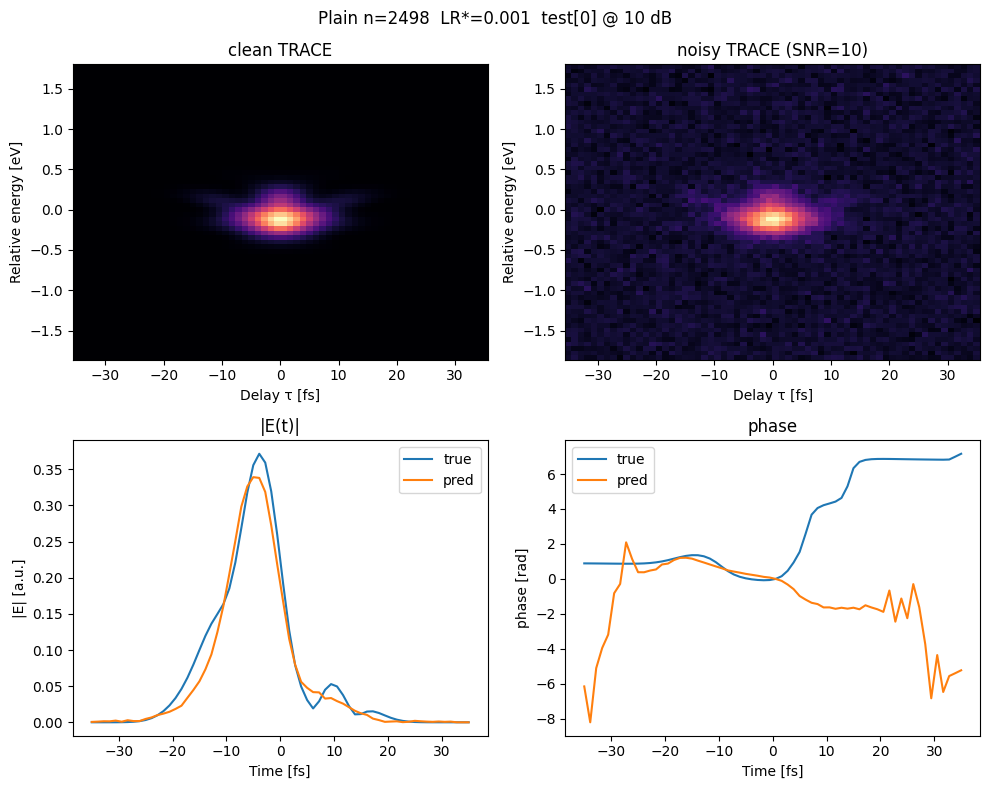

L1_amb: 1.872532844543457
SIM_amb: 0.035289810448910996


In [8]:
model = diag.load_trained_multires(OUT / f"{TAG_FINAL}_model.pt", device=DEVICE)
model.eval()

pulse_cfg = filtered_c1_pulse_config(n=64)
dt = float(pulse_cfg.dt)
t_axis = np.linspace(-pulse_cfg.t_total_fs / 2.0, pulse_cfg.t_total_fs / 2.0, pulse_cfg.n)

# Fixed test index 0, SNR=10
I_clean, E_true = test_loader.dataset[0]
I_clean_b = I_clean.unsqueeze(0).to(DEVICE)
E_np = E_true.detach().cpu().numpy()
g = torch.Generator()
g.manual_seed(999)
noise = torch.randn(I_clean_b.shape, generator=g, dtype=I_clean_b.dtype)
pwr = I_clean_b.pow(2).mean().clamp_min(1e-12)
sigma = torch.sqrt(pwr / (10.0 ** (10.0 / 10.0)))
I_noisy = I_clean_b + sigma * noise.to(DEVICE)

with torch.no_grad():
    E_pred = extract_pulse_prediction(model(I_noisy.unsqueeze(1))).squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_np)
e_pred = unpack_packed_field(E_pred)
e_al = best_l1_ambiguity_field(e_pred, e_true)
amp_p, amp_t = np.abs(e_al), np.abs(e_true)
ph_t, ph_p = unwrap_phases_for_overlay(e_al, e_true)
I_n, tau_axis, omega_plot = prepare_frog_trace_for_plot(
    I_noisy.squeeze(0).cpu().numpy(),
    num_points=pulse_cfg.n,
    dt=dt,
)
I_c, _, _ = prepare_frog_trace_for_plot(
    I_clean_b.squeeze(0).cpu().numpy(),
    num_points=pulse_cfg.n,
    dt=dt,
)
energy_ev = omega_plot * 4.135667696 / (2.0 * np.pi)
extent = [tau_axis[0], tau_axis[-1], energy_ev[0], energy_ev[-1]]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(I_c, aspect="auto", origin="lower", extent=extent, cmap="magma")
axes[0, 0].set_title("clean TRACE")
axes[0, 0].set_xlabel("Delay τ [fs]")
axes[0, 0].set_ylabel("Relative energy [eV]")
axes[0, 1].imshow(I_n, aspect="auto", origin="lower", extent=extent, cmap="magma")
axes[0, 1].set_title("noisy TRACE (SNR=10)")
axes[0, 1].set_xlabel("Delay τ [fs]")
axes[0, 1].set_ylabel("Relative energy [eV]")
axes[1, 0].plot(t_axis, amp_t, label="true")
axes[1, 0].plot(t_axis, amp_p, label="pred")
axes[1, 0].set_title("|E(t)|")
axes[1, 0].set_xlabel("Time [fs]")
axes[1, 0].set_ylabel("|E| [a.u.]")
axes[1, 0].legend()
axes[1, 1].plot(t_axis, ph_t, label="true")
axes[1, 1].plot(t_axis, ph_p, label="pred")
axes[1, 1].set_title("phase")
axes[1, 1].set_xlabel("Time [fs]")
axes[1, 1].set_ylabel("phase [rad]")
axes[1, 1].legend()
plt.suptitle(f"Plain n={N_TRAIN}  LR*={LR_STAR:g}  test[0] @ 10 dB")
plt.tight_layout()
plt.show()

print("L1_amb:", best_l1_ambiguity(e_pred, e_true))
print("SIM_amb:", best_similarity_error_ambiguity(e_pred, e_true))


## Campaign summary row


In [9]:
summary = {
    "n_train": N_TRAIN,
    "model": "plain",
    "lambda": 0.0,
    "LR_star": LR_STAR,
    "batch_size": BATCH_SIZE,
    "best_epoch": meta["best_epoch"],
    "best_score_val_amb": meta["best_score"],
    "stopped_epoch": meta["stopped_epoch"],
    "global_step": meta.get("global_step"),
    "wall_time_data_sec": meta.get("wall_time_data_sec"),
    "wall_time_train_sec": meta.get("wall_time_train_sec"),
    "device": meta.get("device"),
    "data": "filtered_c1",
    "tag": TAG_FINAL,
}
(OUT / "campaign_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))


{
  "n_train": 2498,
  "model": "plain",
  "lambda": 0.0,
  "LR_star": 0.001,
  "batch_size": 300,
  "best_epoch": 70,
  "best_score_val_amb": 1.9460664850473404,
  "stopped_epoch": 95,
  "global_step": 855,
  "wall_time_data_sec": 29.26107809995301,
  "wall_time_train_sec": 1048.6167929999065,
  "device": "cuda",
  "data": "filtered_c1",
  "tag": "n2498_plain_lr0p001_final"
}
